[![Open In Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/EQuS/jaxquantum/blob/main/docs/documentation/tutorials/sparse_dia_backend.ipynb)

In [1]:
# !pip install git+https://github.com/EQuS/jaxquantum.git  # Uncomment when running in Colab.

# SparseDIA Backend

*This is an executable IPython Notebook tutorial.*

jaxquantum supports a **SparseDIA** (sparse diagonal) storage format alongside the default dense and BCOO backends.
Pass `implementation="sparse_dia"` (or `implementation=jqt.QarrayImplType.SPARSE_DIA`) to any operator
constructor to get a SparseDIA-backed Qarray.

**How SparseDIA stores a matrix**

Instead of storing all non-zero values and their indices (as BCOO does), SparseDIA stores only the
diagonal *values* in a compact 2-D array of shape `(n_diags, N)`, together with a static
Python tuple of integer diagonal offsets.
For a matrix of size $N$ with $d$ non-zero diagonals:

| Format | Memory | Index overhead |
|--------|--------|----------------|
| Dense  | $O(N^2)$ | — |
| BCOO   | $O(\mathrm{nnz})$ with `(row, col)` index pairs | Yes |
| SparseDIA | $O(d \cdot N)$ | **No** |

Because the offsets are *static* (marked `pytree_node=False`), JAX unrolls all diagonal loops
at compile time — there is no dynamic indexing or scatter/gather overhead at runtime.

**When to prefer SparseDIA over BCOO**

SparseDIA is ideal for the operators that appear most often in quantum optics and circuit QED:
annihilation ($\hat a$), creation ($\hat a^\dagger$), number ($\hat n$), and Kerr ($\hat n^2$).
All of these have $O(1)$ non-zero diagonals, so SparseDIA stores them with *zero* index overhead
and every arithmetic operation reduces to a handful of aligned slice multiplications.

This tutorial covers:

1. **SparseDIA basics** — creating and inspecting the diagonal structure.
2. **Arithmetic that stays SparseDIA** — addition, subtraction, matmul, dag, kron.
3. **Sparse-native operations** — trace, norm, `keep_only_diag_elements`.
4. **Integer matrix power** — `powm()` stays SparseDIA via binary exponentiation.
5. **Decaying harmonic oscillator** — master equation simulation with a SparseDIA Hamiltonian.
6. **Conversions** — to/from dense and BCOO.

In [2]:
%load_ext autoreload
%autoreload 2

In [3]:
import jaxquantum as jqt
import jax.numpy as jnp
import matplotlib.pyplot as plt

## 1. SparseDIA Basics

Pass `implementation="sparse_dia"` to any operator constructor.
The resulting Qarray stores only the non-zero diagonals, not the full matrix.

In [4]:
N = 10

a    = jqt.destroy(N,  implementation="sparse_dia")
adag = jqt.create(N,   implementation="sparse_dia")
n_op = jqt.num(N,      implementation="sparse_dia")
eye  = jqt.identity(N, implementation="sparse_dia")

print("a is sparse_dia:", a.is_sparse_dia)
print("implementation: ", a.impl_type)

a is sparse_dia: True
implementation:  QarrayImplType.SPARSE_DIA


In [5]:
# Inspect the diagonal structure — offsets are static Python metadata
from jaxquantum.core.sparse_dia import SparseDiaImpl

impl = a._impl  # SparseDiaImpl
print("destroy offsets:", impl._offsets)   # (1,) — one super-diagonal (a_{n-1,n})
print("diags shape:    ", impl._diags.shape)  # (1, N)
print()

impl_n = n_op._impl
print("num offsets:    ", impl_n._offsets)  # (0,) — main diagonal only
print("diags shape:    ", impl_n._diags.shape)

# a†a should equal n̂ — verify the offset structure
adag_a = adag @ a
print()
print("adag@a is sparse_dia:", adag_a.is_sparse_dia)
print("adag@a offsets:       ", adag_a._impl._offsets)  # (0,)

destroy offsets: (1,)
diags shape:     (1, 10)

num offsets:     (0,)
diags shape:     (1, 10)

adag@a is sparse_dia: True
adag@a offsets:        (0,)


## 2. Arithmetic That Stays SparseDIA

When both operands are SparseDIA, all standard operations remain SparseDIA.
Addition computes the **union of offsets** at Python (compile) time, so the output
diagonal structure is always known statically.

In [6]:
# --- Addition: union of offsets ---
# destroy has offset (1,); create has offset (-1,)
# sum X = a + a† has offsets (-1, 1)
X = a + adag
print("(a + a†) is sparse_dia:", X.is_sparse_dia)
print("(a + a†) offsets:       ", X._impl._offsets)  # (-1, 1)

# Scalar shift adds a scaled identity (offset 0) without densification
H_osc = n_op + 0.5
print()
print("(n + 0.5) is sparse_dia:", H_osc.is_sparse_dia)
print("(n + 0.5) offsets:       ", H_osc._impl._offsets)  # (0,)

# --- Matrix multiply: SparseDIA @ SparseDIA → SparseDIA ---
adag_a = adag @ a
print()
print("(a† @ a) is sparse_dia:", adag_a.is_sparse_dia)
# Verify a†a = n̂ numerically
print("tr(a†a)  =", float(jnp.real(jqt.tr(adag_a))),  "(expected", N*(N-1)//2, ")")
print("tr(n̂)    =", float(jnp.real(jqt.tr(n_op))))

(a + a†) is sparse_dia: True
(a + a†) offsets:        (-1, 1)

(n + 0.5) is sparse_dia: True
(n + 0.5) offsets:        (0,)

(a† @ a) is sparse_dia: True
tr(a†a)  = 45.0 (expected 45 )
tr(n̂)    = 45.0


/opt/miniconda3/envs/jax-framework/lib/python3.9/site-packages/jax/_src/ops/scatter.py:96: FutureWarning: scatter inputs have incompatible types: cannot safely cast value from dtype=complex128 to dtype=float64 with jax_numpy_dtype_promotion='standard'. In future JAX releases this will result in an error.
  warnings.warn(
/opt/miniconda3/envs/jax-framework/lib/python3.9/site-packages/jax/_src/ops/scatter.py:138: ComplexWarning: Casting complex values to real discards the imaginary part
  return lax_internal._convert_element_type(out, dtype, weak_type)


In [7]:
# --- dag: conjugate transpose stays SparseDIA ---
# dag() negates every offset and rearranges stored values.
a_dag = a.dag()
print("a.dag() is sparse_dia:", a_dag.is_sparse_dia)
print("a offsets:     ", a._impl._offsets)       # (1,)  — destroy is super-diagonal
print("a.dag offsets: ", a_dag._impl._offsets)   # (-1,) — create is sub-diagonal

# --- kron: SparseDIA ⊗ SparseDIA → SparseDIA ---
# For two modes the two-mode ladder operator a⊗I has offset kA*m + kB = 1*N + 0 = N
a2 = jqt.tensor(a, eye)   # a ⊗ I_{N}
print()
print("(a ⊗ I) is sparse_dia:", a2.is_sparse_dia)
print("(a ⊗ I) offsets:       ", a2._impl._offsets)  # (N,) = (10,)

a.dag() is sparse_dia: True
a offsets:      (1,)
a.dag offsets:  (-1,)

(a ⊗ I) is sparse_dia: True
(a ⊗ I) offsets:        (10,)


## 3. Sparse-Native Operations

Trace, norm, and diagonal extraction all operate directly on the stored diagonal values
— no densification ever occurs.

In [8]:
# Trace: reads offset-0 diagonal directly — O(N), not O(N²)
print("tr(n̂)  =", float(jnp.real(jqt.tr(n_op))))   # 0+1+…+9 = 45
print("tr(eye) =", float(jnp.real(jqt.tr(eye))))    # N = 10

# Trace norm of a SparseDIA density matrix (operator) — computed from stored diagonal
# SparseDIA is designed for square operators; density matrices are built via the
# dense path and then converted to SparseDIA.
rho3 = jqt.ket2dm(jqt.basis(N, 3)).to_sparse_dia()
print()
print("norm(ρ₃)  =", float(jnp.real(jqt.norm(rho3))))  # 1.0

# keep_only_diag_elements: extracts offset-0 diagonal, drops all others
H_noisy = H_osc + 0.1 * X   # offsets (-1, 0, 1)
diag_only = jqt.keep_only_diag_elements(H_noisy)
print()
print("H_noisy offsets:   ", H_noisy._impl._offsets)    # (-1, 0, 1)
print("diag_only offsets: ", diag_only._impl._offsets)  # (0,) — only main diagonal
print("diag_only == H_osc:", jnp.allclose(diag_only.to_dense().data, H_osc.to_dense().data))

tr(n̂)  = 45.0
tr(eye) = 10.0

norm(ρ₃)  = 1.0


/opt/miniconda3/envs/jax-framework/lib/python3.9/site-packages/jax/_src/ops/scatter.py:96: FutureWarning: scatter inputs have incompatible types: cannot safely cast value from dtype=complex128 to dtype=float64 with jax_numpy_dtype_promotion='standard'. In future JAX releases this will result in an error.
  warnings.warn(
/opt/miniconda3/envs/jax-framework/lib/python3.9/site-packages/jax/_src/ops/scatter.py:138: ComplexWarning: Casting complex values to real discards the imaginary part
  return lax_internal._convert_element_type(out, dtype, weak_type)



H_noisy offsets:    (-1, 0, 1)
diag_only offsets:  (0,)
diag_only == H_osc: True


`powm(n)` raises a SparseDIA matrix to the $n$-th integer power using **binary exponentiation**
— only $O(\log n)$ SparseDIA @ SparseDIA multiplications, all staying SparseDIA.

This is particularly useful for building anharmonic terms such as $\hat{n}^2$ (Kerr),
$\hat{n}^3$ (anharmonic ladder), or checking commutator identities.

In [9]:
# n̂² (Kerr anharmonicity) — stays SparseDIA
n_sq = n_op.powm(2)
print("n̂² is sparse_dia:", n_sq.is_sparse_dia)
print("n̂² offsets:       ", n_sq._impl._offsets)  # (0,) — still diagonal!

# Verify against dense calculation
n_dense = jqt.num(N)
n_sq_dense = n_dense @ n_dense
print("Matches dense n²: ", jnp.allclose(n_sq.to_dense().data, n_sq_dense.data))

# Higher power — a^3 chains three super-diagonals, giving offset 3
a_cubed = a.powm(3)
print()
print("a³ is sparse_dia:", a_cubed.is_sparse_dia)
print("a³ offsets:       ", a_cubed._impl._offsets)  # (3,)

# Verify a^0 = identity
a_zero = a.powm(0)
print()
print("a^0 offsets:", a_zero._impl._offsets)  # (0,) — identity
print("a^0 == eye: ", jnp.allclose(a_zero.to_dense().data, eye.to_dense().data))

n̂² is sparse_dia: True
n̂² offsets:        (0,)
Matches dense n²:  True

a³ is sparse_dia: True
a³ offsets:        (3,)

a^0 offsets: (0,)
a^0 == eye:  True


In [10]:
# Build a Kerr Hamiltonian: H = ω n̂ - (K/2) n̂(n̂-1)
# All terms are diagonal → H stays SparseDIA with offset (0,)
omega = 1.0   # oscillator frequency
K     = 0.05  # Kerr anharmonicity

H_kerr = omega * n_op - (K / 2) * n_op.powm(2) + (K / 2) * n_op
print("H_kerr is sparse_dia:", H_kerr.is_sparse_dia)
print("H_kerr offsets:       ", H_kerr._impl._offsets)  # (0,)

# Eigenvalues: E_n = ω*n - (K/2)*n*(n-1)
E = omega * jnp.arange(N) - (K / 2) * jnp.arange(N) * (jnp.arange(N) - 1)
print("Analytic E_n:", E[:5])
print("Stored diag: ", H_kerr._impl._diags[0, :5])

H_kerr is sparse_dia: True
H_kerr offsets:        (0,)
Analytic E_n: [0.   1.   1.95 2.85 3.7 ]
Stored diag:  [0.  +0.j 1.  +0.j 1.95+0.j 2.85+0.j 3.7 +0.j]


## 4. Decaying Harmonic Oscillator

We simulate a single bosonic mode starting in Fock state $|n_0\rangle$ with photon-loss rate $\kappa$:

$$\dot{\rho} = -i[\omega\,\hat{n},\,\rho] + \kappa\!\left(\hat{a}\rho\hat{a}^\dagger - \tfrac{1}{2}\{\hat{a}^\dagger\hat{a},\rho\}\right)$$

The analytic expectation value decays as $\langle\hat{n}\rangle(t) = n_0\,e^{-\kappa t}$.

> **How SparseDIA plugs into `mesolve`:**
> The Hamiltonian is stored as a `SparseDiaData` pytree.  Inside the ODE right-hand side
> jaxquantum calls `H.data @ rho_state` which dispatches to `SparseDiaData.__matmul__`,
> computing the product as $d$ aligned slice multiplications — never materialising
> the full $N\times N$ matrix.  The ODE *state* (density matrix $\rho$) remains dense
> throughout integration.

In [11]:
N     = 20
omega = 1.0   # oscillator frequency
kappa = 0.2   # photon-loss rate
n0    = 4     # initial Fock state |n0⟩

# Build operators with SparseDIA
H     = omega * jqt.num(N, implementation="sparse_dia")
c_ops = jqt.Qarray.from_list([jnp.sqrt(kappa) * jqt.destroy(N, implementation="sparse_dia")])

print("H is sparse_dia:     ", H.is_sparse_dia)
print("c_ops is sparse_dia: ", c_ops.is_sparse_dia)

rho0   = jqt.ket2dm(jqt.basis(N, n0))
tlist  = jnp.linspace(0.0, 30.0, 300)
result = jqt.mesolve(
    H, rho0, tlist,
    c_ops=c_ops,
    solver_options=jqt.SolverOptions.create(progress_meter=False),
)
print("result shape (T, N, N):", result.data.shape)

H is sparse_dia:      True
c_ops is sparse_dia:  True
result shape (T, N, N): (300, 20, 20)


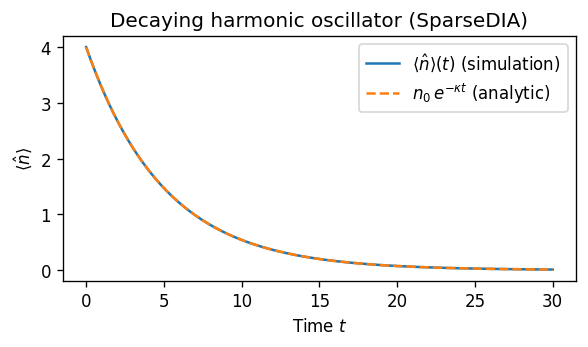

In [12]:
# Expectation value ⟨n̂⟩(t) = tr(n̂ ρ(t)) — batched over time
n_expect = jnp.real(jqt.tr(jqt.num(N, implementation="sparse_dia") @ result))

fig, ax = plt.subplots(figsize=(5, 3), dpi=120)
ax.plot(tlist, n_expect,                           label=r"$\langle\hat{n}\rangle(t)$ (simulation)")
ax.plot(tlist, n0 * jnp.exp(-kappa * tlist), "--", label=r"$n_0\,e^{-\kappa t}$ (analytic)")
ax.set_xlabel("Time $t$")
ax.set_ylabel(r"$\langle\hat{n}\rangle$")
ax.set_title("Decaying harmonic oscillator (SparseDIA)")
ax.legend()
fig.tight_layout()

## 5. Conversions

SparseDIA interoperates with the dense and BCOO backends via explicit conversion methods
or automatically through type promotion.

| Source → Target | Method |
|---|---|
| Dense → SparseDIA | `q.to_sparse_dia()` |
| SparseDIA → Dense | `q.to_dense()` |
| SparseDIA → BCOO | `q.to_sparse_bcoo()` |
| BCOO → SparseDIA | `q.to_sparse_dia()` (via dense) |

**Type promotion:** when a SparseDIA Qarray is combined with a Dense or BCOO Qarray,
the result uses the type with the higher promotion order.
SparseDIA has the lowest promotion order (0), so it always promotes up:
SparseDIA + Dense → Dense, SparseDIA + BCOO → BCOO.

In [13]:
a_dia   = jqt.destroy(N, implementation="sparse_dia")
a_dense = jqt.destroy(N)          # dense
a_bcoo  = jqt.destroy(N, implementation="sparse_bcoo")

# Explicit conversions
print("to_dense:      ", a_dia.to_dense().is_dense)
print("to_sparse_bcoo:", a_dia.to_sparse_bcoo().is_sparse_bcoo)
print("dense → dia:   ", a_dense.to_sparse_dia().is_sparse_dia)

# Round-trip: SparseDIA → dense → SparseDIA
a_rt = a_dia.to_dense().to_sparse_dia()
print()
print("Round-trip correct:", jnp.allclose(a_rt.to_dense().data, a_dia.to_dense().data))

# Type promotion in mixed arithmetic
mixed_dia_dense = a_dia + a_dense   # SparseDIA + Dense  → Dense
mixed_dia_bcoo  = a_dia + a_bcoo    # SparseDIA + BCOO   → BCOO
print()
print("SparseDIA + Dense → dense:      ", mixed_dia_dense.is_dense)
print("SparseDIA + BCOO  → sparse_bcoo:", mixed_dia_bcoo.is_sparse_bcoo)

to_dense:       True
to_sparse_bcoo: True
dense → dia:    True

Round-trip correct: True

SparseDIA + Dense → dense:       True
SparseDIA + BCOO  → sparse_bcoo: True
